In [151]:
import pandas as pd

In [152]:
df = pd.read_csv(r'C:\Users\iago_\hipermercado_projeto\dataset\superstore_data.csv')
df.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,11/5/2014,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,8/4/2014,0,6,...,11,0,34,2,3,1,2,7,1,0


In [153]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [154]:
df.columns = df.columns.str.lower()

df['dt_customer'] = pd.to_datetime(df['dt_customer'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   2240 non-null   int64         
 1   year_birth           2240 non-null   int64         
 2   education            2240 non-null   str           
 3   marital_status       2240 non-null   str           
 4   income               2216 non-null   float64       
 5   kidhome              2240 non-null   int64         
 6   teenhome             2240 non-null   int64         
 7   dt_customer          2240 non-null   datetime64[us]
 8   recency              2240 non-null   int64         
 9   mntwines             2240 non-null   int64         
 10  mntfruits            2240 non-null   int64         
 11  mntmeatproducts      2240 non-null   int64         
 12  mntfishproducts      2240 non-null   int64         
 13  mntsweetproducts     2240 non-null   int64  

In [155]:
#encontrei valores atipicos na coluna categórica
df['marital_status'] = df['marital_status'].replace({
    'Alone': 'Single',
    'Absurd': 'Other',
    'YOLO': 'Other'
})

In [156]:
df.isna().sum()
#coluna income com 24 valores ausentes

id                      0
year_birth              0
education               0
marital_status          0
income                 24
kidhome                 0
teenhome                0
dt_customer             0
recency                 0
mntwines                0
mntfruits               0
mntmeatproducts         0
mntfishproducts         0
mntsweetproducts        0
mntgoldprods            0
numdealspurchases       0
numwebpurchases         0
numcatalogpurchases     0
numstorepurchases       0
numwebvisitsmonth       0
response                0
complain                0
dtype: int64

In [157]:
df['income'].describe()

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: income, dtype: float64

C:\Users\iago_\AppData\Local\Temp\ipykernel_5304\616620773.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['income'].dropna(), vert=False)


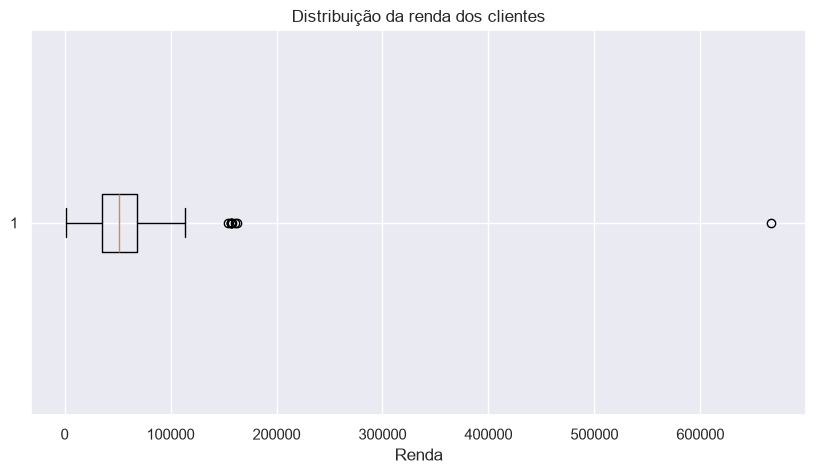

In [158]:
import seaborn as sns
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 5))

plt.boxplot(df['income'].dropna(), vert=False)

plt.title('Distribuição da renda dos clientes')
plt.xlabel('Renda')

plt.show()

*Valores Atipicos na coluna Income*

Indetifiquei valores atipicos na coluna income e temos 24 valores ausentes por mais que a media e a mediana possuam valores proximos irei optar pelo preenchimento com a mediana 
pois é uma medida menos sensivel a valores extremos. 

In [159]:
df['income'] = df['income'].fillna(df['income'].median())
#estou acessando a coluna do df e substituindo os valores ausentes usando o metodo fillna() com a mediana da coluna income.

In [160]:
df['income'].isna().sum()

np.int64(0)

In [161]:
renda_alta = 0

for renda in df['income']:
    if renda >= 200000:
        renda_alta += 1

print(renda_alta)

1


In [162]:
renda_alta_2 = 0

for renda in df['income']:
    if renda >= 125000:
        renda_alta_2 += 1

print(renda_alta_2)

8


In [163]:
print('Média com o outlier:')
print(df['income'].mean())

print('\nMédia sem o cliente de income 666666:')
print(df[df['income'] < 200000]['income'].mean())

print('\nMediana:')
print(df['income'].median())

Média com o outlier:
52237.97544642857

Média sem o cliente de income 666666:
51963.55471192497

Mediana:
51381.5


In [164]:
df = df[df['income'] != 666666].copy()
df['income'].max()
#criando um df em que na coluna income estejam todos os valores diferentes de 666666.

np.float64(162397.0)

Foi identificado um valor de renda de 666.666, muito distante dos demais valores da distribuição. Apesar de seu impacto sobre a média geral ser pequeno, o registro foi considerado um valor extremo e removido para evitar possíveis distorções nas etapas posteriores da análise e modelagem. Os demais valores elevados foram mantidos por serem considerados plausíveis.

In [165]:
print(df.duplicated().sum())
#checando valores duplicados

0


In [166]:
df['age'] = 2026 - df['year_birth']
print(df['age'].head())

0    56
1    65
2    68
3    59
4    37
Name: age, dtype: int64


In [167]:
nao_aderiram = df[df['response'] == 0]
print(nao_aderiram.head(3))

      id  year_birth   education marital_status   income  kidhome  teenhome  \
2  10476        1958  Graduation        Married  67267.0        0         1   
3   1386        1967  Graduation       Together  32474.0        1         1   
7   1991        1967  Graduation       Together  44931.0        0         1   

  dt_customer  recency  mntwines  ...  mntsweetproducts  mntgoldprods  \
2  2014-05-13        0       134  ...                 2            30   
3  2014-11-05        0        10  ...                 0             0   
7  2014-01-18        0        78  ...                 0             7   

   numdealspurchases  numwebpurchases  numcatalogpurchases  numstorepurchases  \
2                  1                3                    2                  5   
3                  1                1                    0                  2   
7                  1                2                    1                  3   

   numwebvisitsmonth  response  complain  age  
2                

In [168]:
nao_aderiram['education'].value_counts()

education
Graduation    974
PhD           385
Master        313
2n Cycle      181
Basic          52
Name: count, dtype: int64

In [169]:
aderiram = df[df['response'] == 1]

idade_media_0 = nao_aderiram['age'].mean().round()
idade_media_1 = aderiram['age'].mean().round()
print(f'Idade média dos clientes que não foram a favor da campanha: {idade_media_0}')
print()
print(f'Idade média dos clientes que foram a favor da campanha: {idade_media_1}')

Idade média dos clientes que não foram a favor da campanha: 57.0

Idade média dos clientes que foram a favor da campanha: 57.0


In [170]:
print(nao_aderiram['kidhome'].value_counts())
nao_aderiram['teenhome'].value_counts()

kidhome
0    1071
1     788
2      46
Name: count, dtype: int64


teenhome
1    938
0    920
2     47
Name: count, dtype: int64

In [171]:
df['dependents'] = df['kidhome'] + df['teenhome']
df[['kidhome', 'teenhome', 'dependents']].head()

,kidhome,teenhome,dependents
0,0,0,0
1,0,0,0
2,0,1,1
3,1,1,2
4,1,0,1


In [172]:
def family_profile(row):
    if row['kidhome'] == 0 and row['teenhome'] == 0:
        return 'Sem dependentes'
    elif row['kidhome'] > 0 and row['teenhome'] == 0:
        return 'Somente crianças'
    elif row['kidhome'] == 0 and row['teenhome'] > 0:
        return 'Somente adolescentes'
    else:
        return 'Crianças e adolescentes'
    

df['family_profile'] = df.apply(family_profile, axis=1)
df['family_profile'].value_counts()
#criando uma função para termos o perfil da familia dos clientes

family_profile
Somente adolescentes       655
Sem dependentes            638
Somente crianças           519
Crianças e adolescentes    427
Name: count, dtype: int64

In [173]:
nao_aderiram['family_profile'] = nao_aderiram.apply(family_profile, axis=1)
nao_aderiram['family_profile'].value_counts()

family_profile
Somente adolescentes       602
Sem dependentes            469
Somente crianças           451
Crianças e adolescentes    383
Name: count, dtype: int64

In [174]:
aderiram['family_profile'] = aderiram.apply(family_profile, axis=1)
aderiram['family_profile'].value_counts()

family_profile
Sem dependentes            169
Somente crianças            68
Somente adolescentes        53
Crianças e adolescentes     44
Name: count, dtype: int64

In [175]:
df['response'].value_counts()

response
0    1905
1     334
Name: count, dtype: int64

O dado bruto já sugere algo interessante: entre quem aderiu, 169 de 334 não têm dependentes, cerca de 50,6%. Entre quem não aderiu, são 469 de 1.905, cerca de 24,6%. Essa diferença é grande.

In [176]:
resumo_dependentes = (
    df.assign(sem_dependentes=df['dependents'] == 0)
      .groupby('response')
      .agg(
          total_clientes=('response', 'size'),
          sem_dependentes=('sem_dependentes', 'sum')
      )
)

resumo_dependentes['percentual_sem_dependentes'] = (
    resumo_dependentes['sem_dependentes']
    / resumo_dependentes['total_clientes']
    * 100
)

resumo_dependentes

,total_clientes,sem_dependentes,percentual_sem_dependentes
response,,,
0,1905,469,24.619423
1,334,169,50.598802


In [177]:
for response, grupo in [(1, 'aderiram'), (0, 'não aderiram')]:
    total = int(resumo_dependentes.loc[response, 'total_clientes'])
    sem_dependentes = int(
        resumo_dependentes.loc[response, 'sem_dependentes']
    )
    percentual = resumo_dependentes.loc[
        response, 'percentual_sem_dependentes'
    ]

    print(
        f'Entre os clientes que {grupo}, '
        f'{sem_dependentes} de {total} não têm dependentes '
        f'({percentual:.1f}%).'
    )

Entre os clientes que aderiram, 169 de 334 não têm dependentes (50.6%).
Entre os clientes que não aderiram, 469 de 1905 não têm dependentes (24.6%).


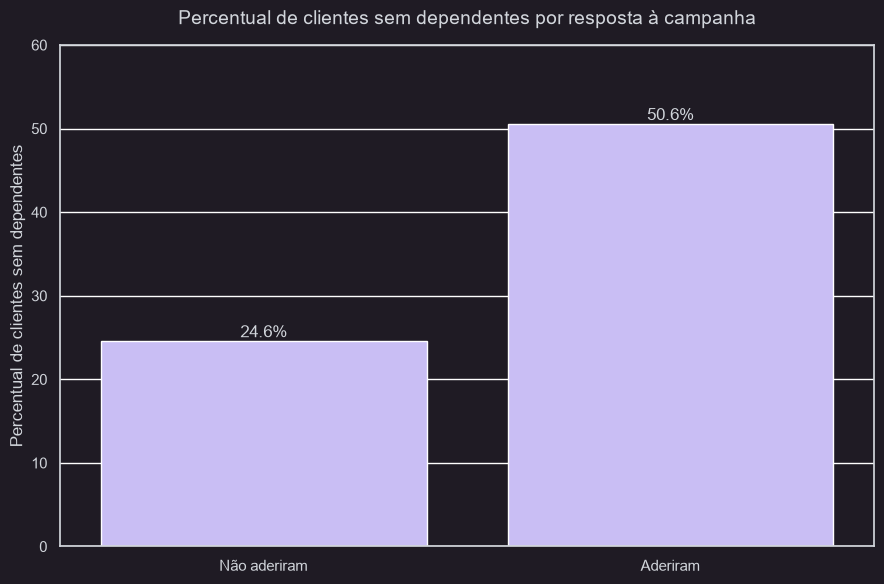

In [178]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcula a porcentagem de clientes sem dependentes em cada resposta
dados_grafico = (
    df.assign(sem_dependentes=df['dependents'] == 0)
      .groupby('response')
      .agg(
          total_clientes=('response', 'size'),
          sem_dependentes=('sem_dependentes', 'sum')
      )
      .reset_index()
)

dados_grafico['percentual_sem_dependentes'] = (
    dados_grafico['sem_dependentes']
    / dados_grafico['total_clientes']
    * 100
)

dados_grafico['grupo'] = dados_grafico['response'].map({
    0: 'Não aderiram',
    1: 'Aderiram'
})

# Estilo e gráfico
sns.set_theme(style='darkgrid')

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#1f1b24')
ax.set_facecolor('#1f1b24')

sns.barplot(
    data=dados_grafico,
    x='grupo',
    y='percentual_sem_dependentes',
    color='#c4b5fd',
    ax=ax
)

# Valores no topo das barras
for barra in ax.patches:
    altura = barra.get_height()
    ax.annotate(
        f'{altura:.1f}%',
        (barra.get_x() + barra.get_width() / 2, altura),
        ha='center',
        va='bottom',
        color='#d1d5db',
        fontsize=12
    )

ax.set_title(
    'Percentual de clientes sem dependentes por resposta à campanha',
    color='#d1d5db',
    fontsize=14,
    pad=15
)
ax.set_xlabel('')
ax.set_ylabel('Percentual de clientes sem dependentes', color='#d1d5db')

ax.tick_params(colors='#d1d5db')
ax.set_ylim(0, 60)

for borda in ax.spines.values():
    borda.set_color('#d1d5db')

plt.tight_layout()
plt.show()

In [179]:
# Mantém somente clientes que possuem pelo menos um dependente
df_dependentes = df[df['dependents'] > 0].copy()

# Agrupa categorias semelhantes para uma leitura mais clara
mapa_situacao_civil = {
    'Married': 'Casado / em união',
    'Together': 'Casado / em união',
    'Single': 'Solteiro',
    'Alone': 'Solteiro',
    'Divorced': 'Divorciado',
    'Widow': 'Viúvo'
}

df_dependentes['situacao_civil'] = (
    df_dependentes['marital_status']
    .map(mapa_situacao_civil)
    .fillna('Outros')
)

# Conta e calcula o percentual dentro de cada grupo de resposta
resumo_civil = (
    df_dependentes
    .groupby(['response', 'situacao_civil'])
    .size()
    .reset_index(name='quantidade_clientes')
)

resumo_civil['percentual'] = (
    resumo_civil.groupby('response')['quantidade_clientes']
    .transform(lambda x: x / x.sum() * 100)
)

resumo_civil['resposta_campanha'] = resumo_civil['response'].map({
    0: 'Não aderiram',
    1: 'Aderiram'
})

resumo_civil

,response,situacao_civil,quantidade_clientes,percentual,resposta_campanha
0,0,Casado / em união,968,67.409471,Não aderiram
1,0,Divorciado,152,10.584958,Não aderiram
2,0,Outros,1,0.069638,Não aderiram
3,0,Solteiro,274,19.080780,Não aderiram
4,0,Viúvo,41,2.855153,Não aderiram
5,1,Casado / em união,91,55.151515,Aderiram
6,1,Divorciado,22,13.333333,Aderiram
7,1,Outros,1,0.606061,Aderiram
8,1,Solteiro,42,25.454545,Aderiram
9,1,Viúvo,9,5.454545,Aderiram


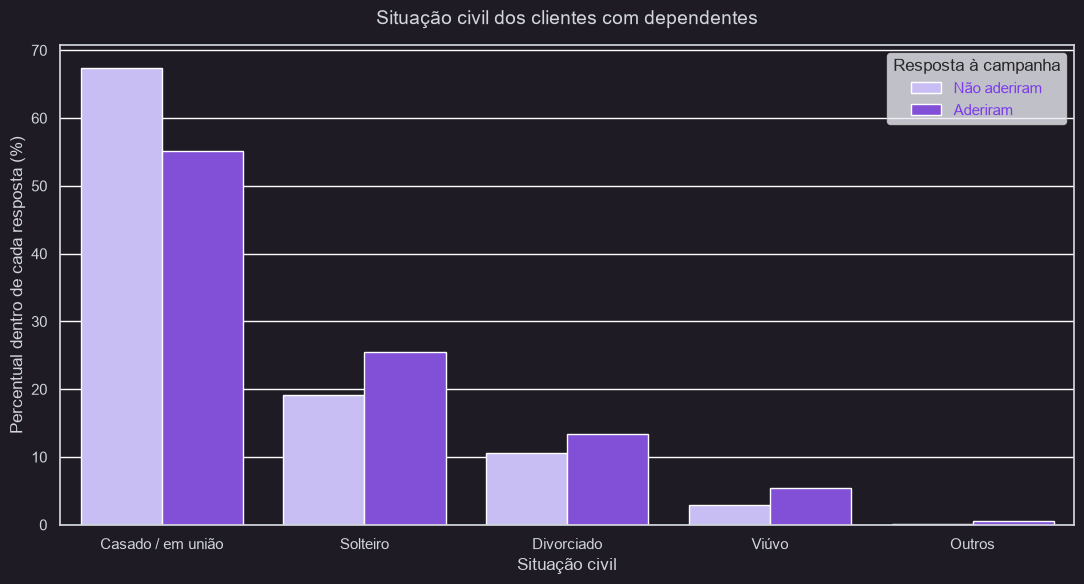

In [180]:
ordem_situacao = [
    'Casado / em união',
    'Solteiro',
    'Divorciado',
    'Viúvo',
    'Outros'
]

sns.set_theme(style='darkgrid')

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#1f1b24')
ax.set_facecolor('#1f1b24')

sns.barplot(
    data=resumo_civil,
    x='situacao_civil',
    y='percentual',
    hue='resposta_campanha',
    order=ordem_situacao,
    palette=['#c4b5fd', '#7c3aed'],
    ax=ax
)

ax.set_title(
    'Situação civil dos clientes com dependentes',
    color='#d1d5db',
    fontsize=14,
    pad=15
)
ax.set_xlabel('Situação civil', color='#d1d5db')
ax.set_ylabel('Percentual dentro de cada resposta (%)', color='#d1d5db')
ax.tick_params(colors='#d1d5db')
ax.legend(
    title='Resposta à campanha',
    labelcolor='#7c3aed',
    title_fontproperties={'weight': 'normal'}
)

for borda in ax.spines.values():
    borda.set_color('#d1d5db')

plt.tight_layout()
plt.show()

In [181]:
media_renda_aderiram = df[df['response'] == 1].groupby('family_profile')['income'].mean().round()
media_renda_nao_aderiram = df[df['response'] == 0].groupby('family_profile')['income'].mean().round()
print(f'Renda media dos que aderiram a campanha {media_renda_aderiram}')
print('=' * 60)
print(f'Renda media dos que não aderiram a campanha {media_renda_nao_aderiram}')

Renda media dos que aderiram a campanha family_profile
Crianças e adolescentes    44084.0
Sem dependentes            74435.0
Somente adolescentes       61786.0
Somente crianças           33931.0
Name: income, dtype: float64
Renda media dos que não aderiram a campanha family_profile
Crianças e adolescentes    44552.0
Sem dependentes            62407.0
Somente adolescentes       57565.0
Somente crianças           33833.0
Name: income, dtype: float64


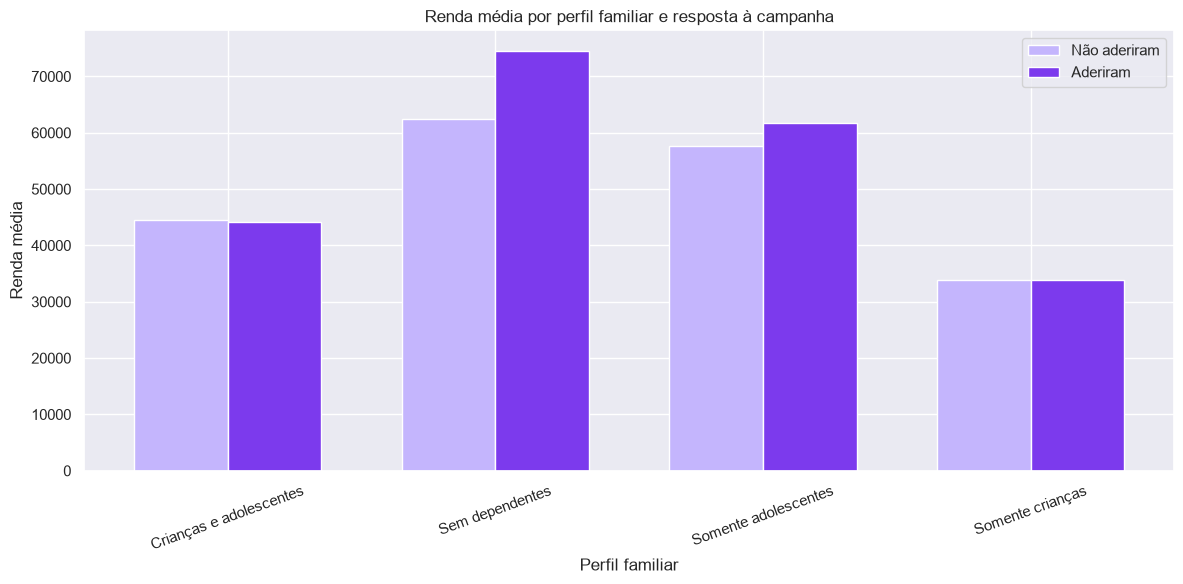

In [182]:
import numpy as np
import matplotlib.pyplot as plt

# Garante que os perfis familiares estejam na mesma ordem nas duas variáveis
perfis = media_renda_nao_aderiram.index.union(
    media_renda_aderiram.index
)

renda_nao_aderiram = media_renda_nao_aderiram.reindex(perfis)
renda_aderiram = media_renda_aderiram.reindex(perfis)

posicoes = np.arange(len(perfis))
largura_barra = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    posicoes - largura_barra / 2,
    renda_nao_aderiram,
    width=largura_barra,
    label='Não aderiram',
    color='#c4b5fd'
)

ax.bar(
    posicoes + largura_barra / 2,
    renda_aderiram,
    width=largura_barra,
    label='Aderiram',
    color='#7c3aed'
)

ax.set_title('Renda média por perfil familiar e resposta à campanha')
ax.set_xlabel('Perfil familiar')
ax.set_ylabel('Renda média')

ax.set_xticks(posicoes)
ax.set_xticklabels(perfis, rotation=20)

ax.legend()
plt.tight_layout()
plt.show()

# Resumo — Análise do Perfil Demográfico dos Clientes

Após realizar a exploração e o cruzamento dos dados para entender o perfil dos clientes que **aderiram à campanha** e daqueles que **não aderiram**, ainda não é possível chegar a uma conclusão clara sobre qual perfil demográfico deve ser priorizado na campanha.

Apesar de alguns padrões sutis se destacarem entre os grupos, as diferenças encontradas até o momento não são suficientes para definir com clareza o perfil ideal de cliente.

Dessa forma, a investigação seguirá para a **análise do perfil comportamental dos clientes em relação ao hipermercado**, buscando entender **como compram, com que frequência consomem e se esses comportamentos apresentam relação com a decisão de aderir ou não à campanha**.

In [183]:
#Agrupando e calculando a media de consumos dos principais produtos para comparar com os que aderiram quais diferenças eles apresentam. 
media_gastos_nao_aderiram = nao_aderiram.groupby(
    'family_profile')[
        ["mntwines", 
         "mntfruits", 
         "mntmeatproducts", 
         "mntfishproducts", 
         "mntsweetproducts", 
         "mntgoldprods"]].mean().round()

print('Media gasto sem dependentes(não aderiram)') 
print(media_gastos_nao_aderiram.loc['Sem dependentes'])
print('='*40)
print('Media gasto com Crianças e adolescentes(não aderiram)')
print(media_gastos_nao_aderiram.loc['Crianças e adolescentes'])

Media gasto sem dependentes(não aderiram)
mntwines            416.0
mntfruits            49.0
mntmeatproducts     334.0
mntfishproducts      74.0
mntsweetproducts     50.0
mntgoldprods         60.0
Name: Sem dependentes, dtype: float64
Media gasto com Crianças e adolescentes(não aderiram)
mntwines            121.0
mntfruits             6.0
mntmeatproducts      45.0
mntfishproducts       9.0
mntsweetproducts      8.0
mntgoldprods         20.0
Name: Crianças e adolescentes, dtype: float64


In [184]:
print('Media de gastos somente crianças(não aderiram)')
print(media_gastos_nao_aderiram.loc['Somente crianças'])
print('='*40)
print('Media de gastos somente adolescentes(não aderiram)')
print(media_gastos_nao_aderiram.loc['Somente adolescentes'])

Media de gastos somente crianças(não aderiram)
mntwines            75.0
mntfruits           10.0
mntmeatproducts     47.0
mntfishproducts     15.0
mntsweetproducts    10.0
mntgoldprods        20.0
Name: Somente crianças, dtype: float64
Media de gastos somente adolescentes(não aderiram)
mntwines            395.0
mntfruits            27.0
mntmeatproducts     134.0
mntfishproducts      36.0
mntsweetproducts     28.0
mntgoldprods         55.0
Name: Somente adolescentes, dtype: float64


In [185]:
media_gastos_aderiram = aderiram.groupby(
    'family_profile')[
        ["mntwines", 
         "mntfruits", 
         "mntmeatproducts", 
         "mntfishproducts", 
         "mntsweetproducts", 
         "mntgoldprods"]].mean().round()

print('Media de gastos sem dependentes(Aderiram)')
print(media_gastos_aderiram.loc['Sem dependentes'])
print('='*40)
print('Media de gastos com Crianças e Adolescentes(Aderiram)')
print(media_gastos_aderiram.loc['Crianças e adolescentes'])

Media de gastos sem dependentes(Aderiram)
mntwines            686.0
mntfruits            63.0
mntmeatproducts     479.0
mntfishproducts      83.0
mntsweetproducts     62.0
mntgoldprods         75.0
Name: Sem dependentes, dtype: float64
Media de gastos com Crianças e Adolescentes(Aderiram)
mntwines            205.0
mntfruits             8.0
mntmeatproducts      69.0
mntfishproducts       9.0
mntsweetproducts      6.0
mntgoldprods         38.0
Name: Crianças e adolescentes, dtype: float64


In [186]:
print('Media de gastos somente crianças(Aderiram)')
print(media_gastos_aderiram.loc['Somente crianças'])
print('='*40)
print('Media de gastos somente adolescentes(Aderiram)')
print(media_gastos_aderiram.loc['Somente adolescentes'])

Media de gastos somente crianças(Aderiram)
mntwines            122.0
mntfruits            10.0
mntmeatproducts      62.0
mntfishproducts      14.0
mntsweetproducts     10.0
mntgoldprods         34.0
Name: Somente crianças, dtype: float64
Media de gastos somente adolescentes(Aderiram)
mntwines            655.0
mntfruits            21.0
mntmeatproducts     189.0
mntfishproducts      36.0
mntsweetproducts     28.0
mntgoldprods         72.0
Name: Somente adolescentes, dtype: float64


In [187]:
media_gastos_aderiram.head()

,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods
family_profile,,,,,,
Crianças e adolescentes,205.0,8.0,69.0,9.0,6.0,38.0
Sem dependentes,686.0,63.0,479.0,83.0,62.0,75.0
Somente adolescentes,655.0,21.0,189.0,36.0,28.0,72.0
Somente crianças,122.0,10.0,62.0,14.0,10.0,34.0


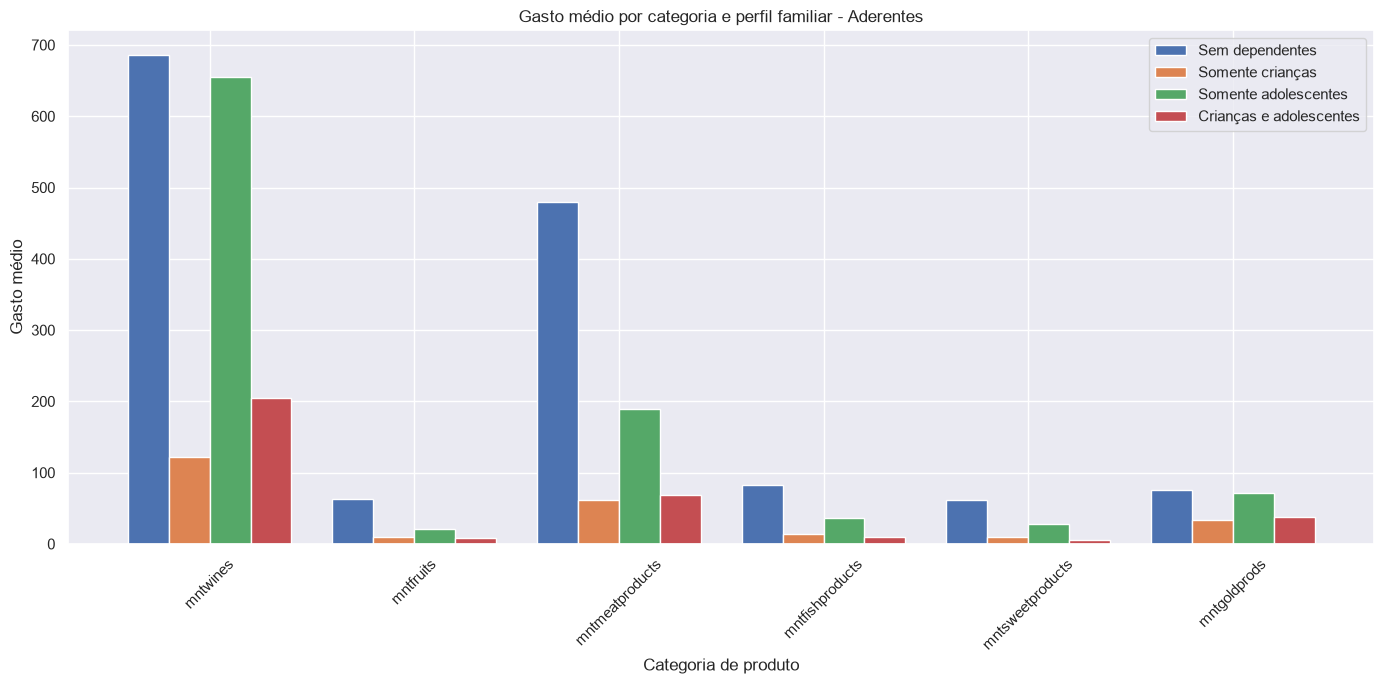

In [188]:
gastos_aderiram_plot = media_gastos_aderiram.reset_index()

import numpy as np
import matplotlib.pyplot as plt

categorias = [
    'mntwines',
    'mntfruits',
    'mntmeatproducts',
    'mntfishproducts',
    'mntsweetproducts',
    'mntgoldprods'
]

x = np.arange(len(categorias))
largura = 0.2

sem_dependentes = gastos_aderiram_plot[
    gastos_aderiram_plot['family_profile'] == 'Sem dependentes'
][categorias].values[0]

somente_criancas = gastos_aderiram_plot[
    gastos_aderiram_plot['family_profile'] == 'Somente crianças'
][categorias].values[0]

somente_adolescentes = gastos_aderiram_plot[
    gastos_aderiram_plot['family_profile'] == 'Somente adolescentes'
][categorias].values[0]

criancas_adolescentes = gastos_aderiram_plot[
    gastos_aderiram_plot['family_profile'] == 'Crianças e adolescentes'
][categorias].values[0]

plt.figure(figsize=(14, 7))

plt.bar(
    x - 1.5 * largura,
    sem_dependentes,
    width=largura,
    label='Sem dependentes'
)

plt.bar(
    x - 0.5 * largura,
    somente_criancas,
    width=largura,
    label='Somente crianças'
)

plt.bar(
    x + 0.5 * largura,
    somente_adolescentes,
    width=largura,
    label='Somente adolescentes'
)

plt.bar(
    x + 1.5 * largura,
    criancas_adolescentes,
    width=largura,
    label='Crianças e adolescentes'
)

plt.xticks(x, categorias, rotation=45)

plt.title('Gasto médio por categoria e perfil familiar - Aderentes')
plt.xlabel('Categoria de produto')
plt.ylabel('Gasto médio')

plt.legend()
plt.tight_layout()
plt.show()

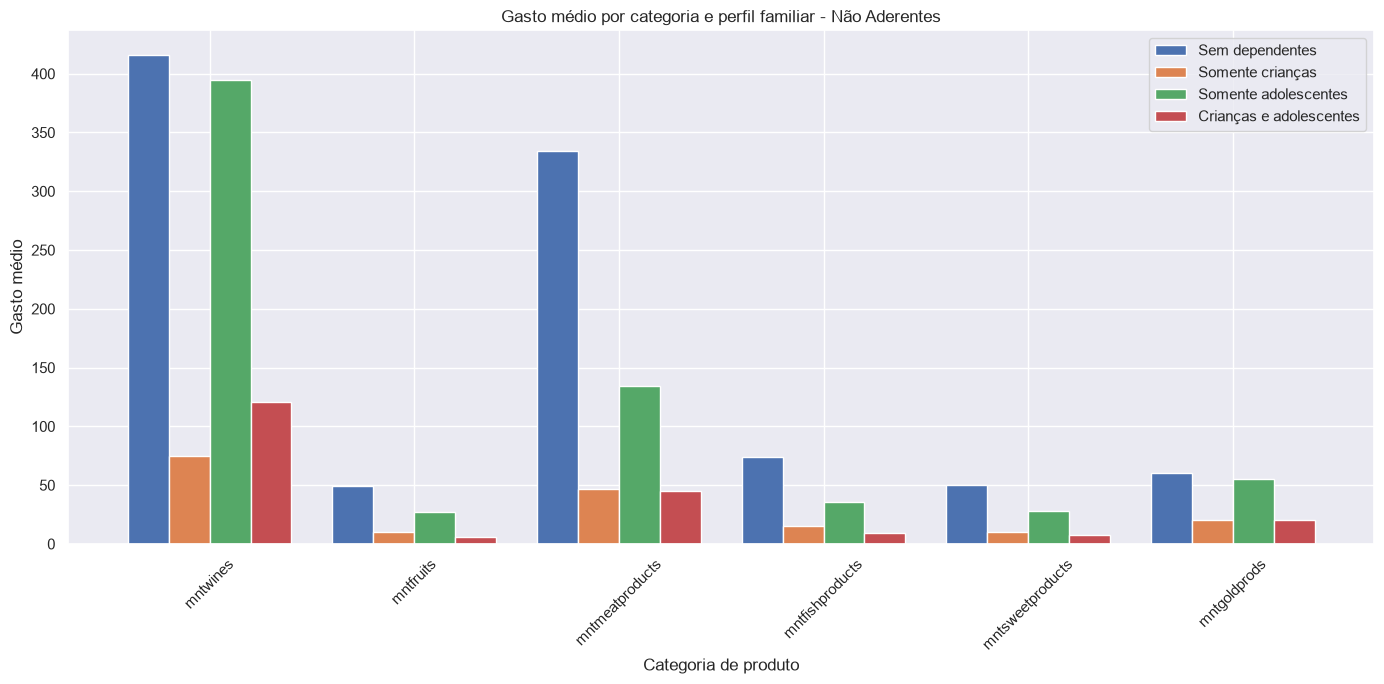

In [189]:
gastos_nao_aderiram_plot = media_gastos_nao_aderiram.reset_index()

import numpy as np
import matplotlib.pyplot as plt

categorias = [
    'mntwines',
    'mntfruits',
    'mntmeatproducts',
    'mntfishproducts',
    'mntsweetproducts',
    'mntgoldprods'
]

x = np.arange(len(categorias))
largura = 0.2

sem_dependentes = gastos_nao_aderiram_plot[
    gastos_nao_aderiram_plot['family_profile'] == 'Sem dependentes'
][categorias].values[0]

somente_criancas = gastos_nao_aderiram_plot[
    gastos_nao_aderiram_plot['family_profile'] == 'Somente crianças'
][categorias].values[0]

somente_adolescentes = gastos_nao_aderiram_plot[
    gastos_nao_aderiram_plot['family_profile'] == 'Somente adolescentes'
][categorias].values[0]

criancas_adolescentes = gastos_nao_aderiram_plot[
    gastos_nao_aderiram_plot['family_profile'] == 'Crianças e adolescentes'
][categorias].values[0]

plt.figure(figsize=(14, 7))

plt.bar(
    x - 1.5 * largura,
    sem_dependentes,
    width=largura,
    label='Sem dependentes'
)

plt.bar(
    x - 0.5 * largura,
    somente_criancas,
    width=largura,
    label='Somente crianças'
)

plt.bar(
    x + 0.5 * largura,
    somente_adolescentes,
    width=largura,
    label='Somente adolescentes'
)

plt.bar(
    x + 1.5 * largura,
    criancas_adolescentes,
    width=largura,
    label='Crianças e adolescentes'
)

plt.xticks(x, categorias, rotation=45)

plt.title('Gasto médio por categoria e perfil familiar - Não Aderentes')
plt.xlabel('Categoria de produto')
plt.ylabel('Gasto médio')

plt.legend()
plt.tight_layout()
plt.show()

Observação: Os graficos de gasto médio para as categorias de produtos ainda não nos dizem um padrão preciso apenas que as familias com apenas adolescente e as familias sem dependentes em todas as categorias possuem uma média de consumo maior em relação aos outros perfis familiares.

In [190]:
media_gastos_n_aderentes = (
    nao_aderiram.groupby(['family_profile', 'marital_status'])
    .agg(
        quantidade_clientes=('id', 'count'),
        media_vinhos=('mntwines', 'mean'),
        media_frutas=('mntfruits', 'mean'),
        media_carnes=('mntmeatproducts', 'mean'),
        media_peixes=('mntfishproducts', 'mean'),
        media_doces=('mntsweetproducts', 'mean'),
        media_gold=('mntgoldprods', 'mean')
    )
    .round()
)
media_gastos.head(40)

quantidade_clientes  media_vinhos  \
family_profile          marital_status                                      
Crianças e adolescentes Divorced                         42         115.0   
                        Married                         145         128.0   
                        Single                           74         111.0   
                        Together                        109         126.0   
                        Widow                            13          76.0   
Sem dependentes         Divorced                         32         332.0   
                        Married                         188         400.0   
                        Other                             1         240.0   
                        Single                          102         392.0   
                        Together                        129         477.0   
                        Widow                            17         436.0   
Somente adolescentes    Divorced                         72         464.0   
                        Married                         245         399.0   
                        Other                             1         322.0   
                        Single                           93         377.0   
                        Together                        165         374.0   
                        Widow                            26         370.0   
Somente crianças        Divorced                         38          93.0   
                        Married                         188          88.0   
                        Single                          107          47.0   
                        Together                        116          75.0   
                        Widow                             2           4.0   

                                        media_frutas  media_carnes  \
family_profile          marital_status                               
Crianças e adolescentes Divorced                 5.0          42.0   
                        Married                  6.0          41.0   
                        Single                   8.0          53.0   
                        Together                 7.0          47.0   
                        Widow                    4.0          41.0   
Sem dependentes         Divorced                35.0         219.0   
                        Married                 48.0         328.0   
                        Other                   67.0         500.0   
                        Single                  47.0         323.0   
                        Together                52.0         380.0   
                        Widow                   61.0         331.0   
Somente adolescentes    Divorced                33.0         145.0   
                        Married                 28.0         139.0   
                        Other                    3.0          50.0   
                        Single                  24.0         127.0   
                        Together                25.0         128.0   
                        Widow                   31.0         117.0   
Somente crianças        Divorced                10.0          40.0   
                        Married                 11.0          56.0   
                        Single                  10.0          39.0   
                        Together                 8.0          41.0   
                        Widow                    1.0           5.0   

                                        media_peixes  media_doces  media_gold  
family_profile          marital_status                                         
Crianças e adolescentes Divorced                 7.0          7.0        20.0  
                        Married                  7.0          6.0        20.0  
                        Single                   9.0          7.0        20.0  
                        Together                12.0         10.0        21.0  
                        Widow 

In [191]:
media_gastos_aderentes = (
    aderiram.groupby(['family_profile', 'marital_status'])
    .agg(
        quantidade_clientes=('id', 'count'),
        media_vinhos=('mntwines', 'mean'),
        media_frutas=('mntfruits', 'mean'),
        media_carnes=('mntmeatproducts', 'mean'),
        media_peixes=('mntfishproducts', 'mean'),
        media_doces=('mntsweetproducts', 'mean'),
        media_gold=('mntgoldprods', 'mean')
    )
    .round()
)
media_gastos.head(40)

quantidade_clientes  media_vinhos  \
family_profile          marital_status                                      
Crianças e adolescentes Divorced                         42         115.0   
                        Married                         145         128.0   
                        Single                           74         111.0   
                        Together                        109         126.0   
                        Widow                            13          76.0   
Sem dependentes         Divorced                         32         332.0   
                        Married                         188         400.0   
                        Other                             1         240.0   
                        Single                          102         392.0   
                        Together                        129         477.0   
                        Widow                            17         436.0   
Somente adolescentes    Divorced                         72         464.0   
                        Married                         245         399.0   
                        Other                             1         322.0   
                        Single                           93         377.0   
                        Together                        165         374.0   
                        Widow                            26         370.0   
Somente crianças        Divorced                         38          93.0   
                        Married                         188          88.0   
                        Single                          107          47.0   
                        Together                        116          75.0   
                        Widow                             2           4.0   

                                        media_frutas  media_carnes  \
family_profile          marital_status                               
Crianças e adolescentes Divorced                 5.0          42.0   
                        Married                  6.0          41.0   
                        Single                   8.0          53.0   
                        Together                 7.0          47.0   
                        Widow                    4.0          41.0   
Sem dependentes         Divorced                35.0         219.0   
                        Married                 48.0         328.0   
                        Other                   67.0         500.0   
                        Single                  47.0         323.0   
                        Together                52.0         380.0   
                        Widow                   61.0         331.0   
Somente adolescentes    Divorced                33.0         145.0   
                        Married                 28.0         139.0   
                        Other                    3.0          50.0   
                        Single                  24.0         127.0   
                        Together                25.0         128.0   
                        Widow                   31.0         117.0   
Somente crianças        Divorced                10.0          40.0   
                        Married                 11.0          56.0   
                        Single                  10.0          39.0   
                        Together                 8.0          41.0   
                        Widow                    1.0           5.0   

                                        media_peixes  media_doces  media_gold  
family_profile          marital_status                                         
Crianças e adolescentes Divorced                 7.0          7.0        20.0  
                        Married                  7.0          6.0        20.0  
                        Single                   9.0          7.0        20.0  
                        Together                12.0         10.0        21.0  
                        Widow 

Os perfis “sem dependentes” e “somente adolescentes” apresentam níveis médios de consumo superiores aos demais perfis familiares em diversas categorias de produtos. Esse padrão aparece inclusive entre clientes que não aderiram à campanha.

In [192]:
#Criando uma coluna com o total de pedidos em cada fonte de capitação. 
aderiram['total_purchases'] = (
    aderiram['numwebpurchases']
    + aderiram['numcatalogpurchases']
    + aderiram['numstorepurchases']
)

nao_aderiram['total_purchases'] = (
    nao_aderiram['numwebpurchases']
    + nao_aderiram['numcatalogpurchases']
    + nao_aderiram['numstorepurchases']
)

In [193]:
media_purchases_aderiram = aderiram.groupby('family_profile').agg({
    'recency': 'mean',
    'numdealspurchases': 'mean',
    'numwebpurchases': 'mean',
    'numcatalogpurchases': 'mean',
    'numstorepurchases': 'mean',
    'numwebvisitsmonth': 'mean',
    'total_purchases': 'mean'
})

media_purchases_aderiram.head()

,recency,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,total_purchases
family_profile,,,,,,,
Crianças e adolescentes,28.159091,5.386364,4.386364,1.795455,4.500000,7.363636,10.681818
Sem dependentes,36.846154,1.076923,5.408284,5.893491,7.538462,3.532544,18.840237
Somente adolescentes,43.849057,3.584906,7.113208,4.641509,6.509434,6.433962,18.264151
Somente crianças,29.823529,2.514706,3.088235,1.220588,3.220588,7.441176,7.529412


In [194]:
media_purchases_n_aderiram = nao_aderiram.groupby('family_profile').agg({
    'recency': 'mean',
    'numdealspurchases': 'mean',
    'numwebpurchases': 'mean',
    'numcatalogpurchases': 'mean',
    'numstorepurchases': 'mean',
    'numwebvisitsmonth': 'mean',
    'total_purchases': 'mean'   
})

media_purchases_n_aderiram.head()

,recency,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,total_purchases
family_profile,,,,,,,
Crianças e adolescentes,52.088773,3.509138,2.843342,0.882507,4.039164,6.281984,7.765013
Sem dependentes,53.496802,1.162047,4.027719,4.349680,7.166311,3.456290,15.543710
Somente adolescentes,49.362126,2.652824,5.400332,3.049834,7.229236,5.099668,15.679402
Somente crianças,51.902439,2.079823,2.713969,0.762749,3.705100,6.736142,7.181818


In [195]:
nao_aderiram['complain'].value_counts()

complain
0    1887
1      18
Name: count, dtype: int64

In [196]:
aderiram['complain'].value_counts()

complain
0    331
1      3
Name: count, dtype: int64

### Reclamações e resposta à campanha

A proporção de clientes que registraram reclamações foi muito baixa nos dois grupos.

- Não aderentes: aproximadamente 0,94% registraram reclamação.
- Aderentes: aproximadamente 0,90% registraram reclamação.

As proporções são praticamente equivalentes, não indicando, nesta etapa da análise,
uma associação relevante entre o registro de reclamações e a resposta à campanha.

Dessa forma, a variável `complain` não apresentou inicialmente um padrão capaz de
diferenciar os clientes aderentes dos não aderentes.

In [ ]:
#Realizando teste de hipooteses utilizando apoio da IA Codex, para sustentar o perfil encontrado ao longo da análise explorátoria.
from scipy import stats
import numpy as np

alpha = 0.05

stat_recency, p_recency = stats.mannwhitneyu(
    aderiram['recency'],
    nao_aderiram['recency'],
    alternative='two-sided'
)

print('HIPÓTESE 1 - RECÊNCIA X ADESÃO')
print(f'Estatística do teste: {stat_recency:.2f}')
print(f'P-value: {p_recency:.4f}')

if p_recency < alpha:
    print('Resultado: rejeitamos H0.')
    print('Existe evidência estatística de diferença na recência entre aderentes e não aderentes.')
else:
    print('Resultado: não rejeitamos H0.')
    print('Não há evidência estatística suficiente de diferença na recência entre os grupos.')

HIPÓTESE 1 - RECÊNCIA X ADESÃO
Estatística do teste: 215874.00
P-value: 0.0000
Resultado: rejeitamos H0.
Existe evidência estatística de diferença na recência entre aderentes e não aderentes.


In [199]:
df['total_purchases'] = (
    df['numwebpurchases']
    + df['numcatalogpurchases']
    + df['numstorepurchases']
)

aderiram = df[df['response'] == 1].copy()
nao_aderiram = df[df['response'] == 0].copy()

stat_purchases, p_purchases = stats.mannwhitneyu(
    aderiram['total_purchases'],
    nao_aderiram['total_purchases'],
    alternative='two-sided'
)

print('HIPÓTESE 2 - TOTAL DE COMPRAS X ADESÃO')
print(f'Estatística do teste: {stat_purchases:.2f}')
print(f'P-value: {p_purchases:.4f}')

if p_purchases < alpha:
    print('Resultado: rejeitamos H0.')
    print('Existe evidência estatística de diferença no total de compras entre aderentes e não aderentes.')
else:
    print('Resultado: não rejeitamos H0.')
    print('Não há evidência estatística suficiente de diferença no total de compras entre os grupos.')

HIPÓTESE 2 - TOTAL DE COMPRAS X ADESÃO
Estatística do teste: 403519.50
P-value: 0.0000
Resultado: rejeitamos H0.
Existe evidência estatística de diferença no total de compras entre aderentes e não aderentes.


## Conclusão da Análise Exploratória

Após realizar a análise exploratória dos dados do hipermercado, buscamos identificar padrões demográficos e comportamentais associados à adesão ao Plano Ouro.

Foram analisadas características como idade, perfil familiar, renda, consumo médio por categoria de produto, quantidade de compras, canais utilizados, recência e histórico de reclamações.

A análise indicou um perfil mais recorrente entre os clientes que aderiram à campanha: clientes com idade média próxima de 57 anos e, principalmente, pertencentes aos perfis familiares **sem dependentes** ou **com somente adolescentes**. Esses grupos também apresentaram maior volume médio de compras e consumo em diferentes categorias de produtos.

Além disso, observamos que os clientes aderentes apresentaram, de maneira geral, **maior quantidade de compras e compras mais recentes** quando comparados aos não aderentes.

A partir desses padrões encontrados durante a EDA, foram realizados testes de hipótese para verificar estatisticamente as diferenças relacionadas à **recência** e ao **total de compras** entre aderentes e não aderentes. Em ambos os testes, a hipótese nula foi rejeitada, fornecendo evidência estatística de que existem diferenças entre os dois grupos nessas características.

Dessa forma, os resultados sugerem que clientes mais ativos no hipermercado, especialmente aqueles com maior histórico de compras e compras mais recentes, representam um público de maior interesse para a campanha. A análise exploratória também indica maior presença de adesão entre clientes sem dependentes ou com somente adolescentes, tornando esses perfis relevantes para a estratégia de segmentação da campanha.